In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\WaterMelon\OneDrive\Desktop\SpringBoard\MetroFlow\data\NYC_subway_traffic_2017-2021.csv")

df.head()

,Unique ID,Datetime,Stop Name,Remote Unit,Line,Connecting Lines,Daytime Routes,North Direction Label,South Direction Label,Division,Structure,Borough,Neighborhood,Latitude,Longitude,Entries,Exits
0,1,2017-02-04 04:00:00,103 St,R180,Lexington Av,6,6,Uptown Bronx,Downtown,IRT,Subway,M,East Harlem,40.790600,-73.947478,403.0,222.0
1,2,2017-02-04 04:00:00,103 St,R191,Broadway - 7Av,1,1,Uptown Bronx,Downtown,IRT,Subway,M,Upper West Side,40.799446,-73.968379,119.0,145.0
2,3,2017-02-04 04:00:00,103 St,R314,8th Av - Fulton St,BC,BC,Uptown Bronx,Downtown Brooklyn,IND,Subway,M,Upper West Side,40.796092,-73.961454,55.0,81.0
3,10,2017-02-04 04:00:00,111 St,R355,Liberty Av,A,A,Manhattan,Lefferts Blvd,IND,Elevated,Q,South Ozone Park/Howard Beach,40.684331,-73.832163,156.0,30.0
4,11,2017-02-04 04:00:00,116 St,R182,Lexington Av,6,6,Uptown Bronx,Downtown,IRT,Subway,M,East Harlem,40.798629,-73.941617,495.0,303.0


In [5]:
df.shape

(4589380, 17)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4589380 entries, 0 to 4589379
Data columns (total 17 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unique ID              int64  
 1   Datetime               str    
 2   Stop Name              str    
 3   Remote Unit            str    
 4   Line                   str    
 5   Connecting Lines       str    
 6   Daytime Routes         str    
 7   North Direction Label  str    
 8   South Direction Label  str    
 9   Division               str    
 10  Structure              str    
 11  Borough                str    
 12  Neighborhood           str    
 13  Latitude               float64
 14  Longitude              float64
 15  Entries                float64
 16  Exits                  float64
dtypes: float64(4), int64(1), str(12)
memory usage: 595.2 MB


In [7]:
df.describe()

,Unique ID,Latitude,Longitude,Entries,Exits
count,4.589380e+06,4.589380e+06,4.589380e+06,4.589380e+06,4.589380e+06
mean,2.342242e+02,4.073121e+01,-7.393783e+01,1.219527e+03,9.709457e+02
std,1.353358e+02,7.637638e-02,5.673617e-02,1.996934e+03,1.683479e+03
min,0.000000e+00,4.057613e+01,-7.403088e+01,0.000000e+00,0.000000e+00
25%,1.170000e+02,4.067984e+01,-7.398503e+01,1.640000e+02,1.400000e+02
50%,2.340000e+02,4.072285e+01,-7.395028e+01,5.280000e+02,3.970000e+02
75%,3.510000e+02,4.077845e+01,-7.390103e+01,1.400000e+03,1.040000e+03
max,4.680000e+02,4.090313e+01,-7.375541e+01,4.037400e+04,4.069700e+04


In [8]:
df.isnull().sum()

Unique ID                     0
Datetime                      0
Stop Name                     0
Remote Unit                   0
Line                          0
Connecting Lines              0
Daytime Routes                0
North Direction Label    146807
South Direction Label    118681
Division                      0
Structure                     0
Borough                       0
Neighborhood                  0
Latitude                      0
Longitude                     0
Entries                       0
Exits                         0
dtype: int64

In [11]:
df["Total_Traffic"] = df["Entries"] + df["Exits"]


In [12]:
print(df[["Entries", "Exits", "Total_Traffic"]].head())

   Entries  Exits  Total_Traffic
0    403.0  222.0          625.0
1    119.0  145.0          264.0
2     55.0   81.0          136.0
3    156.0   30.0          186.0
4    495.0  303.0          798.0


<Axes: xlabel='Stop Name'>

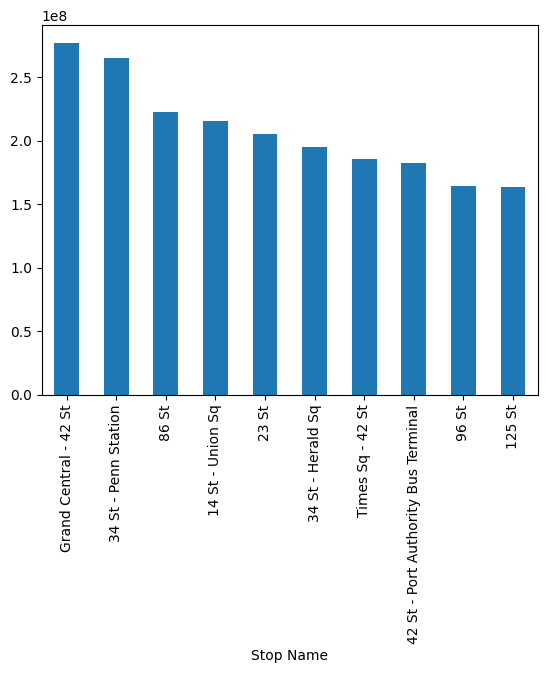

In [13]:
top_stations = (
    df.groupby("Stop Name")
      ["Total_Traffic"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_stations.plot(kind="bar")

## Interpretation for Report

Grand Central–42 St and Penn Station experience the highest passenger traffic, making them major congestion hotspots. These stations should be prioritized for crowd monitoring and train frequency optimization.

In [14]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df["hour"] = df["Datetime"].dt.hour
df["day"] = df["Datetime"].dt.day
df["month"] = df["Datetime"].dt.month
df["year"] = df["Datetime"].dt.year
df["day_of_week"] = df["Datetime"].dt.dayofweek

<Axes: xlabel='hour'>

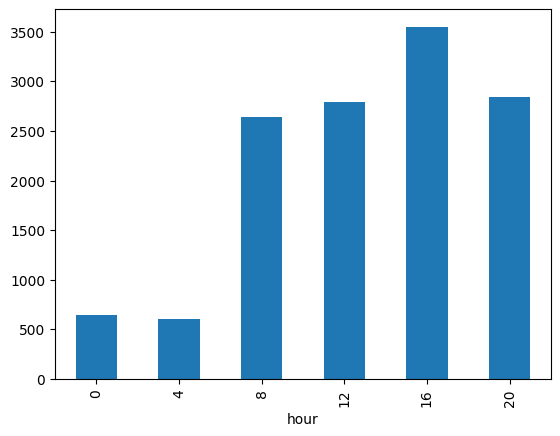

In [15]:
hourly = (
    df.groupby("hour")["Total_Traffic"]
    .mean()
)

hourly.plot(kind="bar")

## Interpretation

Passenger traffic increases significantly during daytime and peaks around 4 PM (16:00), indicating evening rush-hour demand. Traffic is minimal during early morning hours.

<Axes: xlabel='Borough'>

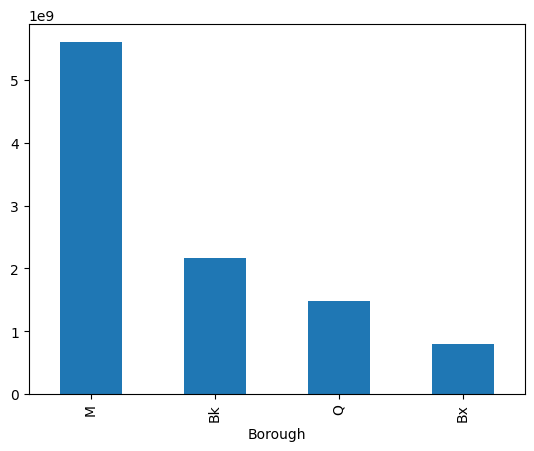

In [17]:
borough_traffic = (
    df.groupby("Borough")["Total_Traffic"]
    .sum()
    .sort_values(ascending=False)
)

borough_traffic.plot(kind="bar")

In [18]:
df.shape

(4589380, 23)

In [19]:
df.isnull().sum()

Unique ID                     0
Datetime                      0
Stop Name                     0
Remote Unit                   0
Line                          0
Connecting Lines              0
Daytime Routes                0
North Direction Label    146807
South Direction Label    118681
Division                      0
Structure                     0
Borough                       0
Neighborhood                  0
Latitude                      0
Longitude                     0
Entries                       0
Exits                         0
Total_Traffic                 0
hour                          0
day                           0
month                         0
year                          0
day_of_week                   0
dtype: int64